# **Manejo de datos faltantes**


### Índice de temas
1. [Datos ruidosos](#1.-Datos-ruidosos)
    * 1.1 [Tipos de datos ruidosos](#1.1-Tipos-de-datos-ruidosos)
    * 1.2 [Datos Erróneos](#1.2-Datos-Erróneos)
    * 1.3 [Datos Faltantes](#1.3-Datos-Faltantes)
    * 1.4 [Dataset: Primer mirada a los datos](#1.4-Dataset:-Primer-mirada-a-los-datos)
        * 1.4.1 [Exploración](#1.4.1-Exploración)
    * 1.5 [Reconocimiento de datos ruidosos](#1.5-Reconocimiento-de-datos-ruidosos)
        * 1.5.1 [Detección de variables con valor cero](#1.5.1-Detección-de-variables-con-valor-cero)
        * 1.5.2 [Exploración de Bedroom2, Bathroom y Distance](#1.5.2-Exploración-de-Bedroom2,-Bathroom-y-Distance)
        * 1.5.3 [Ejercicio](#1.5.3-Ejercicio)
    * 1.6 [Reconocimiento de datos faltantes](#1.6-Reconocimiento-de-datos-faltantes)
    * 1.7 [Librería Missingno](#1.7-Librería-Missingno)
    * 1.8 [Mecanismos de pérdida de datos (MCAR, MAR, MNAR)](#1.8-Mecanismos-de-pérdida-de-datos)
    * 1.9 [Detección de correlaciones](#1.9-Detección-de-correlaciones)
        * 1.9.1 [Matrix plot](#1.9.1-Detección-de-correlaciones-usando-matrix-plot)
        * 1.9.2 [Heatmap](#1.9.2-Detección-de-correlaciones-usando-Heatmap)
2. [Tratamiento del valor faltante](#2.-Tratamiento-del-valor-faltante)
    * 2.1 [Eliminación de datos faltantes](#2.1-Eliminación-de-datos-faltantes)
        * 2.1.1 [Eliminación de casos completos](#2.1.1-Eliminación-de-casos-completos)
        * 2.1.2 [Eliminación de variables](#2.1.2-Eliminación-de-variables)
    * 2.2 [Técnicas de imputación básicas](#2.2-Técnicas-de-imputación)
        * 2.2.1 [Imputar con constante](#2.2.1-Técnicas-Básicas)
        * 2.2.2 [Imputar con valor más frecuente](#2.2.2-Imputar-con-el-valor-más-frecuente)
        * 2.2.3 [Imputar con la media](#2.2.3-Ejercicio:-Imputar-con-la-media)
        * 2.2.4 [Hot Deck](#2.2.4-Hot-Deck)
    * 2.3 [Técnicas de imputación avanzadas](#2.3-Técnicas-de-imputación-avanzadas)
        * 2.3.1 [K-Nearest Neighbor](#2.3.1-K-Nearest-Neighbor-Imputation)
        * 2.3.2 [MICE - Multivariate feature imputation](#2.3.2-Multivariate-feature-imputation)
        * 2.3.3 [Ejercicio](#2.3.3-Ejercicio)
        * 2.3.4 [Otros métodos](#2.3.4-Otros-métodos-de-imputación)


## ⚙️ Configuración inicial

Ejecutar esta celda **antes de cualquier otra**. Instala las librerías necesarias e importa todo lo requerido para el notebook.

In [1]:
# Instalación de dependencias (ejecutar una sola vez)
# !pip install missingno fancyimpute

# Librerías estándar
import numpy as np
import pandas as pd

# Configuración de pandas para cambiar el formatod de como salen los floats
#pd.set_option para configuraciones internas.
#display.float_format es el tipo de cambio que se hará
#Luego esta una función anonima para poner cada número
#con solo 2 decimales. (Solo para alteraciones en salidas)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#ajustar el tamaño de las fuentes, líneas y marcadores de losg ´raficos apra
#que se adapaten al medio donde se van a exponer. 
#.set_context ajusta el tamaño de las fuentes
#"talk" es un preajuste disponible, incrementando el tamaño de todos los elementos.
#hay distintas opciones como "paper" para artículos científicos, 'notebook' para dejarlo
#por defecto y 'poster' para que sea grande para posteres de conferencias. 
sns.set_context('paper')
import plotly.express as px

# Para la visualización de datos faltantes
import missingno as msno

# Imputación avanzada - sklearn
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Datos ruidosos

Una de las conclusiones más importantes de trabajar con información es que los datos nunca se organizan ni se recolectan de forma simple. Los datos del mundo real, al combinar diferentes características y calificaciones de objetos y sujetos, muchas veces contienen errores, lo que requiere una limpieza significativa para ser utilizables. Esto es lo que se conoce como **ruido** en los datos.

Casi todos los conjuntos de datos contienen algo de ruido. Algunos tipos de ruido son más fáciles de corregir que otros. A veces, eliminar el ruido por completo es simplemente imposible. Como se dice en procesamiento de datos: <span style="color:FireBrick">**cuando entra basura, sale basura.**</span>

### 1.1 Tipos de datos ruidosos

* El <span style="color:FireBrick">**dato erróneo**</span> es un dato recolectado con algún error, que lo separa de la generalidad. Debe ser inspeccionado y tratado especialmente para determinar si es un <span style="color:FireBrick">**ruido**</span> o un dato importante con baja probabilidad de ocurrir, es decir un <span style="color:FireBrick">**dato atípico**</span> u <span style="color:FireBrick">**outlier**</span>.

* El <span style="color:FireBrick">**dato faltante**</span> es un dato que no está registrado en la base de datos. Dependiendo de cómo se hayan recolectado los datos, pueden estar marcados con un <span style="color:FireBrick">**NaN**</span>, o con un número fuera de rango como <span style="color:FireBrick">**0**</span> o <span style="color:FireBrick">**-1**</span>. Es muy importante reconocer la codificación de datos faltantes para no confundirlos con un dato válido.

Por ejemplo también un dato faltante puede ser 999 o -999 pues es un dato faltante codificado de otra forma. Y esto puede identificarse con análisis descriptivo. 

### 1.2 Datos Erróneos

Los datos erróneos se dividen en <span style="color:FireBrick">**datos atípicos**</span> y <span style="color:FireBrick">**datos mal codificados**</span>.

Los <span style="color:FireBrick">**datos atípicos**</span> son datos reales que pueden producir demasiada palanca sobre los estadísticos de tendencia central, lo cual los hace candidatos a ser retirados del dataset.

Los <span style="color:FireBrick">**datos mal codificados**</span> son la fuente de error más común. Es importante detectar cuando los datos faltantes fueron codificados como valores fuera de rango, por ejemplo el valor <span style="color:FireBrick">**cero**</span>. Este error suele aparecer cuando se mezclan bases de datos con distinta codificación de datos faltantes.

Acá es donde la importancia de un análisis descriptivo y exploratorio sale a la luz, pues directamente con esto es que puede identificarse. 

Además, por eso mismo es que es necesario leer el diccionario de las bases de datos o variables que se tengan, pues, directamente en estos documentos se puede tener este tipo de información para luego, no cometer ningún error. 

### 1.3 Datos Faltantes

Los datos faltantes se dividen en <span style="color:FireBrick">**datos perdidos**</span> y <span style="color:FireBrick">**datos inexistentes**</span>.

* Un <span style="color:FireBrick">**dato perdido**</span> es un dato que existe pero, dada una recolección fallida o incompleta, no se conoce su valor.

* Un <span style="color:FireBrick">**dato inexistente**</span> es un dato que no puede ser recolectado porque sencillamente no existe.

Python no reconoce la diferencia, por lo cual hay que ser cauteloso. Al leer un archivo con espacios en blanco, automáticamente asigna a ese dato un <span style="color:FireBrick">**NaN**</span>.


### 1.4 Dataset: Primer mirada a los datos

Este es el punto en el que entramos en la parte de la ciencia de datos que necesita mucho de la "intuición de datos": mirar realmente los datos y tratar de averiguar por qué son así y cómo esto afecta el análisis.

<span style="color:FireBrick">**Para lidiar con los valores perdidos**</span>, la pregunta más importante es:

> ❓ **¿Falta este valor porque no se registró o porque no existe?**

Por ejemplo:
- Una casa de 2 dormitorios no incluiría respuesta para el tamaño del tercer dormitorio → **no existe** → mantener como `NaN`.
- Alguien que no quiso reportar sus ingresos → **no se registró** → puede intentarse imputar.

Por ello, es importante diferenciar cuando un dato no existe y cuando es porque no hay registro y entonces allí es que puede imputarse. 

Vamos a trabajar con el dataset <span style="color:FireBrick">**Melbourne Housing Snapshot**</span>, un conjunto reducido de información sobre ventas de propiedades.

#### 1.4.1 Exploración

In [2]:
melb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')

print(f"Dimensiones: {melb_data.shape[0]} filas × {melb_data.shape[1]} columnas")
melb_data.shape

Dimensiones: 13580 filas × 21 columnas


(13580, 21)

In [3]:
melb_data.describe() #estadísticos de variables cuantitativas

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


**Definición de variables** (las filas son *casos*, las columnas son *variables*):

| Variable | Descripción |
|---|---|
| `Suburb` | Barrio / región |
| `Rooms` | Número de habitaciones |
| `Price` | Precio en dólares |
| `Type` | `h`=casa, `u`=unidad/duplex, `t`=townhouse |
| `Distance` | Distancia al CBD |
| `Bedroom2` | N° de dormitorios (fuente alternativa) |
| `Bathroom` | Número de baños |
| `Car` | Espacios de estacionamiento |
| `Landsize` | Tamaño del terreno |
| `BuildingArea` | Tamaño de la construcción |
| `YearBuilt` | Año de construcción |
| `CouncilArea` | Consejo municipal de la zona |

In [4]:
y = melb_data.sample(10, random_state=123)
print(y)
#muestra aleatoria de 10 registros, con semilla 123

              Suburb              Address  Rooms Type      Price Method  \
5799        St Kilda  25/69 Wellington St      2    u  542500.00     PI   
10596   Broadmeadows          48 Walsh St      3    h  386000.00      S   
7471      Ascot Vale         17 Monash St      3    h 1230000.00     PI   
2308          Elwood    2/129 Brighton Rd      2    u  684000.00     SP   
2602   Fitzroy North        264 Barkly St      3    h 1600000.00      S   
3159        Hawthorn           16 Pine St      3    h 1712000.00      S   
5781        St Kilda   1/62 Wellington St      1    u  500000.00     SP   
2443        Essendon      1/19 Cameron Rd      2    u  691000.00     SP   
6005        Sunshine        165 Morris St      3    h  591500.00      S   
6365          Toorak    4/264 Williams Rd      2    u  810000.00     SP   

             SellerG        Date  Distance  Postcode  ...  Bathroom  Car  \
5799         McGrath  10/09/2016      6.10   3182.00  ...      1.00 1.00   
10596  hockingstuart  

### 1.5 Reconocimiento de datos ruidosos

En la muestra vemos variables con valores faltantes reconocidos por pandas como <span style="color:FireBrick">**NaN**</span>, y valores <span style="color:FireBrick">**0**</span> que podrían ser también datos faltantes. (Por eso es que un análisis de variable por variable puede ser determinante pues revisar el contexto de cada variable me puede llevar a descubrir cosas más a fondo)

¿Son estos ceros valores posibles o datos faltantes codificados así?

#### 1.5.1 Detección de variables con valor cero

In [5]:
# Conteo de ceros por columna
#axis=0 cuenta por columna. 
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]
#type(cols)

Distance           6
Bedroom2          16
Bathroom          34
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

Recordemos que tenemos 13 580 casos. La pregunta a responder es: ¿son estos ceros valores posibles de la variable o datos faltantes codificados como 0?

Vamos a trabajar las variables `Bedroom2`, `Bathroom` y `Distance`.

notese que se tiene muy pocos valores para estas variables por lo que puede consedirarse algo raro que sus valores sean cero. 

#### 1.5.2 Exploración de Bedroom2, Bathroom y Distance

##### Tipos de propiedades SIN DORMITORIOS

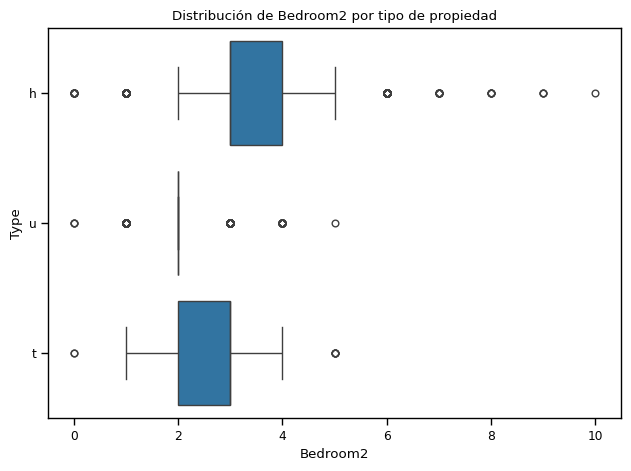

In [6]:
sns.boxplot(data=melb_data[melb_data.Bedroom2 < 20], x='Bedroom2', y='Type')
plt.title('Distribución de Bedroom2 por tipo de propiedad')
plt.tight_layout()

Solo había 16 casos con valores cero. Hay unidades, casas y townhouses sin dormitorios. Podría pensarse en unidades tipo monoambiente, pero es difícil imaginar casas sin dormitorios — ese parece ser un dato faltante, ya que `Bedroom2` proviene de la unión con otra base de datos.

Miremos conjuntamente la variable `Rooms` y la variable `Bedroom2`:

In [7]:
Bedroom2 = melb_data.Bedroom2
Rooms = melb_data.Rooms
#crosstab es como hacer un cont(bedroom2,rooms) en R
pd.crosstab(Bedroom2, Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.00,0,5,8,3,0,0,0,0,0
1.00,663,21,5,2,0,0,0,0,0
2.00,16,3539,162,19,1,0,0,0,0
3.00,2,74,5626,175,18,1,0,0,0
4.00,0,8,73,2473,42,4,0,1,0
5.00,0,1,5,15,531,2,2,0,0
6.00,0,0,0,0,2,59,0,2,0
7.00,0,0,0,0,1,1,8,0,0
8.00,0,0,0,0,1,0,0,4,0


La variable `Rooms` es mucho más informativa que `Bedroom2`. Lo que passa es que bedroom2 es un variable que uso al juntar dos data frames. Además, sabemos que 'Rooms' tiene la misma información, por tanto, simplemente podemos eliminar Bedroom2 y ya podría ser un solución simple para ese caso específico. 

##### Acción: eliminar la variable `Bedroom2`

> ⚠️ **NUNCA ACCIONAR SOBRE EL DATASET ORIGINAL** — siempre trabajar sobre una copia.

In [8]:
melb_df = melb_data.copy()
melb_df = melb_df.drop(['Bedroom2'], axis=1)
melb_df.sample(5, random_state=123)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
5799,St Kilda,25/69 Wellington St,2,u,542500.00,PI,McGrath,10/09/2016,6.10,3182.00,1.00,1.00,0.00,NaN,NaN,Port Phillip,-37.86,144.99,Southern Metropolitan,13240.00
10596,Broadmeadows,48 Walsh St,3,h,386000.00,S,hockingstuart,8/07/2017,14.00,3047.00,1.00,1.00,341.00,71.00,1965.00,Hume,-37.69,144.92,Northern Metropolitan,4294.00
7471,Ascot Vale,17 Monash St,3,h,1230000.00,PI,Nelson,20/05/2017,5.90,3032.00,1.00,2.00,538.00,NaN,NaN,Moonee Valley,-37.78,144.91,Western Metropolitan,6567.00
2308,Elwood,2/129 Brighton Rd,2,u,684000.00,SP,McGrath,19/11/2016,7.70,3184.00,1.00,0.00,0.00,98.00,1930.00,Port Phillip,-37.88,144.99,Southern Metropolitan,8989.00
2602,Fitzroy North,264 Barkly St,3,h,1600000.00,S,Collins,25/02/2017,3.50,3068.00,1.00,0.00,370.00,NaN,NaN,Yarra,-37.78,144.99,Northern Metropolitan,6244.00


clase del 30 de abril - minuto 29. 

##### Tipos de propiedades SIN BAÑOS

Esto nos puede dar indiciós de si los valores son problemáticos o no, pues directamente por ejemplo conecontrar una casa sin baño puede ser un error. 

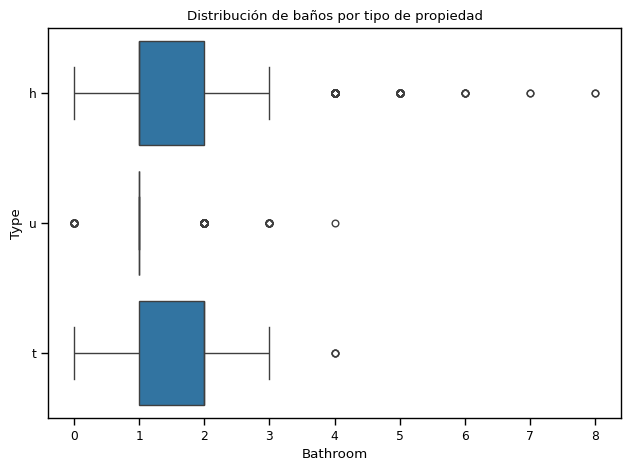

In [9]:
sns.boxplot(data=melb_data, x='Bathroom', y='Type')
plt.title('Distribución de baños por tipo de propiedad')
plt.tight_layout()

In [ ]:
Bathroom = melb_data.Bathroom
#Esto es como un count para 2 variables. 
pd.crosstab(Bathroom, Rooms)

#notese que se puede ver los hogares con un número respectivo de baños
#y habitaciones y se a partir de lo anterior es posible usar un filtro para hacer
#estas verificaciones de que tipo de registros estamos hablando. 

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.00,1,19,11,3,0,0,0,0,0
1.00,674,3117,3250,452,17,2,0,0,0
2.00,6,504,2459,1720,260,20,3,2,0
3.00,0,8,153,469,244,35,5,2,1
4.00,0,0,5,41,47,9,2,2,0
5.00,0,0,1,2,25,0,0,0,0
6.00,0,0,2,0,2,1,0,0,0
7.00,0,0,0,0,1,0,0,1,0
8.00,0,0,0,1,0,0,0,1,0


##### Acción: asumir que propiedades sin baños tienen al menos uno

In [11]:
melb_df.loc[melb_df.Bathroom < 1, 'Bathroom'] = 1

# Verificación: ¿quedaron ceros en el dataset editado?

#contar el número de ceros por columna.
cols2 = melb_df[melb_df == 0].count(axis=0)
print("Ceros en dataset editado:")
print(cols2[cols2 > 0])
print()
print("Ceros en dataset original:")
print(cols[cols > 0])

Ceros en dataset editado:
Distance           6
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

Ceros en dataset original:
Distance           6
Bedroom2          16
Bathroom          34
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64


> Como se puede observar: en el dataset editado ya no está `Bedroom2` y la columna `Bathroom` no tiene ceros.

Nota: ES MUY IMPORTANTE QUE TODO TIPO DE EDICIONES Y BÚSQUEDAS SE HAGAN EN UNA COPIA DE LOS DATOS PARA PODER HACER DIFERENTES TIPOS DE BÚSQUEDA SIN AFECTAR NUESTROS DATOS. 

In [12]:
print("Describe original:")
display(melb_data.describe())
print("Describe editado:")
display(melb_df.describe())

Describe original:


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


Describe editado:


,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,1.54,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,1.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


### <span style="color:FireBrick">**1.5.3 Ejercicio**</span>

Dadas las demás columnas del dataset que tienen ceros, decidir para cada una:
1. ¿Es un cero válido o un dato erróneo/faltante enmascarado?
2. ¿Qué acción tomar?

In [14]:
# Revisa las columnas con ceros que aún quedan
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]
# Tu análisis aquí ↓

,0
Distance,6
Bedroom2,16
Bathroom,34
Car,1026
Landsize,1939
BuildingArea,17


In [ ]:
cols = melb_df[melb_df == 0].count(axis=0)

#forma de obtener los índices del vector(serie)
cols_ceros = cols[cols>0].index

#forma de ver los valores del vector (serie)
cols[cols>0]

In [62]:
melb_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount'],
      dtype='object')

In [ ]:
#A partir de lo anterior las variables que siguen con ceros son: Distance, Car, Landsize y bulding area.

for i in cols_ceros:
    # Se hace directamente .dtype ya que esto es un ATRIBUTO de al serie de pandas. 
    print(melb_df[i].dtype)

cols_ceros
 

#Car: Como es simplemente los espacios para parquear autos, no necesriamente
# es un errore pues puede ser que sean hogares sin espacio para parquear
melb_df[melb_df['Car'] == 0]
melb_df[melb_df['Car'] == 0].shape # se dejan

#Distance al downtown, obligatoriamente debe tener una distancia
#al centrod de la ciudad,no? tal vez se pueda corregir imputando
#con los valores de los hogares que tengan las misma dirección
#peroq que esta variablen o sea cero. 
melb_df[melb_df['Distance'] == 0].shape #son 6
melb_df[melb_df['Distance'] == 0] #son 6

#miremos la dirección y area conuncil de los que son 0
#al seleccionar las variables con [[v1,v2,...]] es como
#un select y hacer [v1] es directamente un pull
melb_df[(melb_df['Distance'] == 0)][['Address','Suburb','CouncilArea']]
#direccion = melb_df[(melb_df['Distance'] == 0)]['Address']
sub = melb_df[(melb_df['Distance'] == 0)]['Suburb']
council = direccion = melb_df[(melb_df['Distance'] == 0)]['CouncilArea']

#Ahora de los que son diferente de cero, pero que sean
# del suburbio o council area de los que si 
melb_df[(melb_df['Suburb'].isin(sub))&
        (melb_df['CouncilArea'].isin(council))&
        (melb_df['Distance']!=0)][['Suburb','Distance']]

# es notable que para todos estos casos la distancia es de 2.8
#por tanto, los ceros, pasana ser 2.8

melb_df[melb_df['Distance']==0] = 2.8 


float64
float64
float64
float64


,Suburb,Distance
3976,Melbourne,2.80
3977,Melbourne,2.80
3978,Melbourne,2.80
3979,Melbourne,2.80
3980,Melbourne,2.80
3981,Melbourne,2.80
3982,Melbourne,2.80
3983,Melbourne,2.80
3984,Melbourne,2.80
3985,Melbourne,2.80



| `Suburb` | Barrio / región |

| `Rooms` | Número de habitaciones |

| `Price` | Precio en dólares |

| `Type` | `h`=casa, `u`=unidad/duplex, `t`=townhouse |

| `Distance` | Distancia al CBD |

| `Bedroom2` | N° de dormitorios (fuente alternativa) |

| `Bathroom` | Número de baños |

| `Car` | Espacios de estacionamiento |

| `Landsize` | Tamaño del terreno |

| `BuildingArea` | Tamaño de la construcción |

| `YearBuilt` | Año de construcción |

| `CouncilArea` | Consejo municipal de la zona |

<font color="yellow">
Nota:

Pandas.series: Es una estructura UNIDIMENSIONAL indexado capaz de contener cualquier tipo de dato. UNA SOLA DIMENSIÓN. Suelen aparecer como el subproducto de un dataframe aparecen cuando se opera sobre una sola variable, por ejemplo,

* Extraer una variable de un data frame.
    ej: df['variable']
* Realizar operaciones de reducción como .sum(), .count() o .mean(). sobre un data frame.

La serie de panda equivale al vector del R, por ejemplo al hacer un pull para obtener la columna de un data.frame. Pero ojo, acá el vector de numpy es diferente a la serie de pandas. 

¿Diferencia entre una serie de pandas y un vector de numpy?
La serie de pandas es una capa superior estructurada, mientras que el vector de Numpy son los datos puros en memoria. 

La serie de pandas maneja índices explícitos para la identificación de cada fila, cosa que el vector de numpy solo tiene identificación mediante índices numéricos. 

Igualmente es posible pasar de serie a vector de numpy con .to_numpy()

La serie ESTA DISEÑADA PARA ANALÍTICA DE DATOS, por lo que maneja de forma nativa e inteligente los datos faltantes


Pandas.DataFrame: Es un tabla de filas y columnas que es un diccionario de series donde todas las series comparten el mismo índice. VARIAS DIMENSIONES. Es directamente el estandar para la representación y manipúlación de datos tabulares. 

Es como en el select del R, que los datos siguen siendo de tipo de dato data.frame. 
</font>

### 1.6 Reconocimiento de datos faltantes

Las bibliotecas de Python representan los números faltantes como <span style="color:FireBrick">**NaN**</span> (*Not a Number*). Detectar cuántos hay y dónde es el primer paso antes de cualquier tratamiento.

**Consecuencias de los datos faltantes:**
- Limitan la capacidad de convertir tipos de datos o visualizar información.
- Reducen el poder estadístico (aumentan la probabilidad de error Tipo II).
- Reducen la representatividad de las muestras.
- Pueden llevar a **conclusiones inválidas** si no se tratan correctamente.

In [15]:
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [40]:
missing_values_count = melb_data.isna().sum()
missing_values_count

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


El dataset donde empezamos a corregir:

In [41]:
melb_df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [47]:
# Porcentaje total de datos faltantes
total_cells = np.product(melb_data.shape)
total_missing = missing_values_count.sum()
pct = (total_missing / total_cells) * 100
print(f"Porcentaje de datos faltantes: {pct:.2f}%")

NameError: name 'total_cells' is not defined

Solo hay un **~4% de datos faltantes**, concentrados en cuatro variables:

| Variable | Faltantes | Tipo |
|---|---|---|
| `Car` | 62 | float64 |
| `BuildingArea` | 6 450 | float64 |
| `YearBuilt` | 5 375 | float64 |
| `CouncilArea` | 1 369 | object |

> La imputación es diferente para variables **categóricas** y **numéricas**, por lo cual es importante distinguir los casos.

### 1.7 Librería Missingno

Text(0.5, 1.0, 'Completitud por variable')

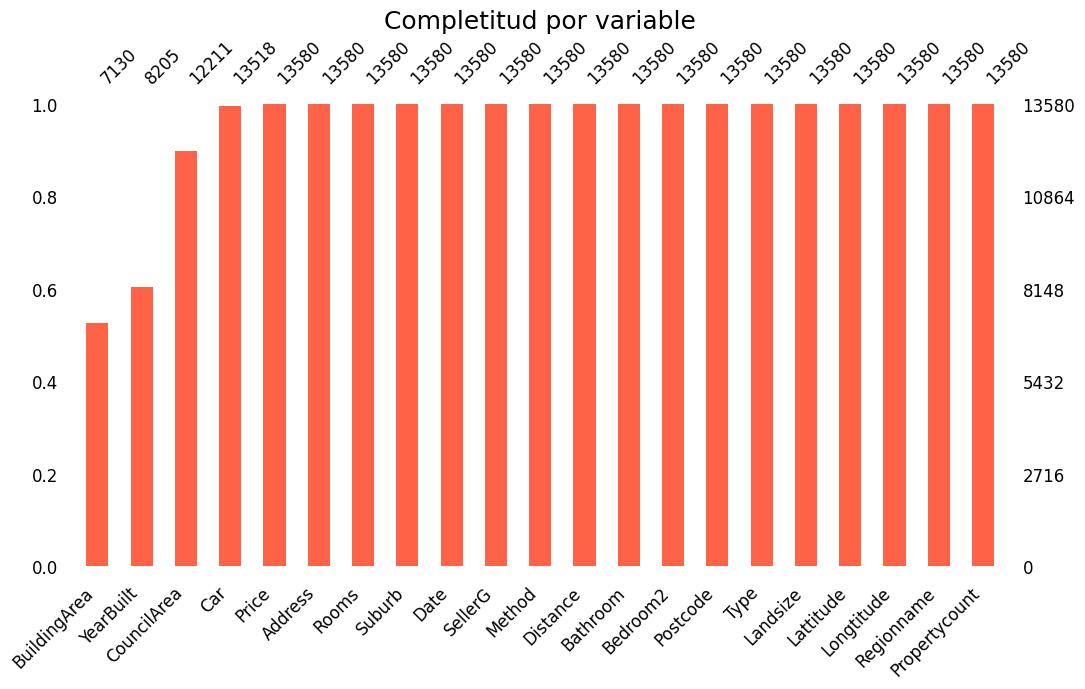

In [19]:
msno.bar(melb_data, figsize=(12, 6), sort="ascending", fontsize=12, color='tomato')
plt.title('Completitud por variable')

Podemos visualizar también las **posiciones** de los datos faltantes en el dataset usando `matrix()`. El gráfico aparece en blanco donde faltan valores.

<Axes: >

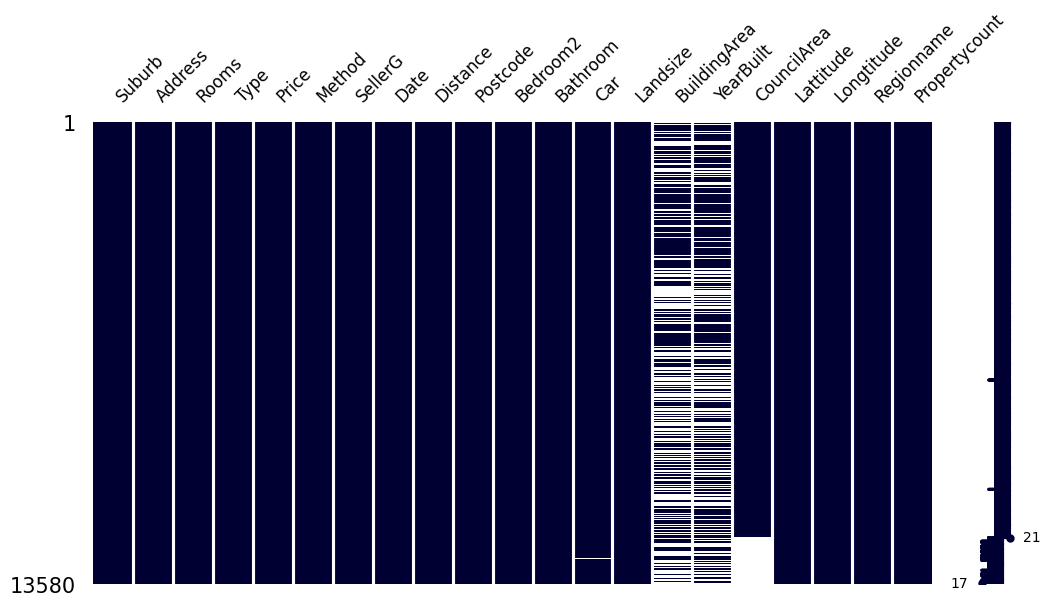

In [20]:
msno.matrix(melb_data, figsize=(12, 6), fontsize=12, color=[0, 0, 0.2])

Con una muestra de 200 datos, podemos observar mejor las correlaciones entre los datos faltantes. Para poder accionar sin incorporar nuevos errores, es necesario corroborar que el mecanismo de pérdida sea aleatorio.

<Axes: >

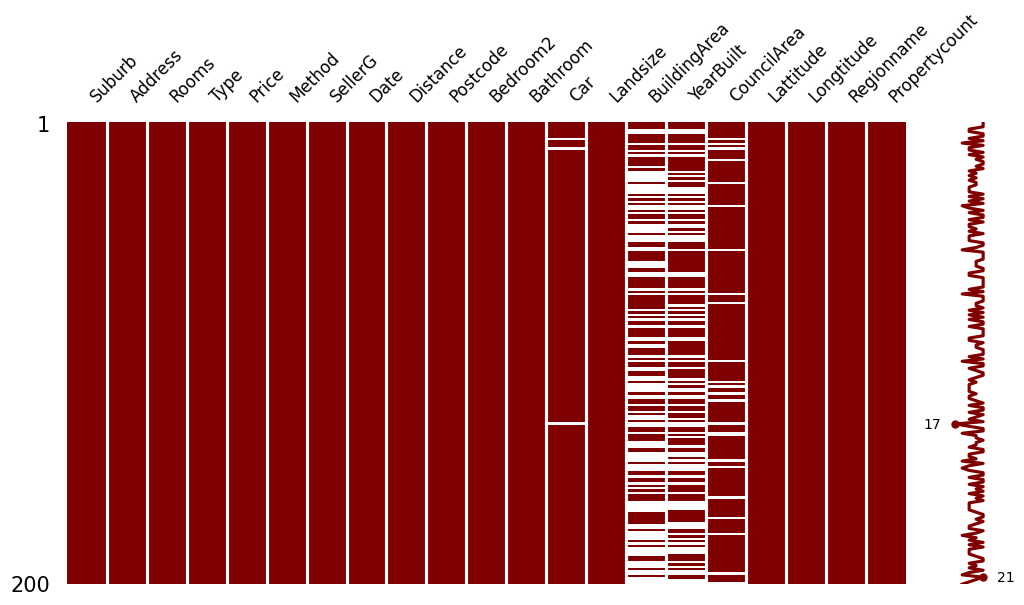

In [21]:
msno.matrix(melb_data.sample(200), figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

### 1.8 Mecanismos de pérdida de datos

> 💡 Este tema fue cubierto en la Semana 5 del curso. Antes de tratar los datos faltantes, es **fundamental** entender por qué faltan.

Se distinguen tres mecanismos estándar:

---

#### <span style="color:Red">1. MCAR — *Missing Completely at Random*</span>

Los valores faltantes de una variable **no están asociados** con otras variables del dataset ni con la misma variable.

**Implicación práctica:** Los datos observados son una muestra aleatoria de todos los datos. Las operaciones simples de Pandas (medias, varianzas) **no se ven afectadas**.

---

#### <span style="color:Red">2. MAR — *Missing at Random*</span>

La pérdida **no es aleatoria**, pero puede ser explicada completamente como función de **otras variables con información completa**.

**Ejemplo en nuestro dataset:** `YearBuilt` podría faltar más frecuentemente en propiedades más antiguas, pero eso está explicado por otras variables disponibles.

**Implicación práctica:** Se puede imputar usando las variables observadas como predictores.

---

#### <span style="color:Red">3. MNAR — *Missing Not at Random*</span>

La pérdida **depende del valor perdido mismo** o de datos no observados.

**Ejemplo:** Los ingresos altos tienden a no ser reportados (el valor faltante está relacionado con ser alto).

**Implicación práctica:** El más difícil de tratar. La imputación estándar puede introducir sesgos importantes.

---

> ⚠️ **¿Por qué importa conocer el mecanismo?**
> Porque la decisión de eliminar casos, eliminar columnas o imputar **depende del tipo de mecanismo**. Eliminar filas en un escenario MNAR introduce sesgos graves.

### 1.9 Detección de correlaciones

La existencia de correlación entre la presencia/ausencia de datos faltantes en determinadas variables es una señal de **falta de aleatoriedad** en el mecanismo de pérdida (descarta MCAR). Aún así, puede existir una relación entre variables que permita imputar el dato perdido.

#### 1.9.1 Detección de correlaciones usando matrix plot

La variable `Car` tiene pocos datos faltantes. Es razonable pensar que es un error de carga, ya que cero en esta variable implicaría que la propiedad no tiene espacio para estacionar.

In [22]:
Car = melb_data.Car

fig = px.histogram(Car, nbins=100,
                   labels={'value': 'Car', 'count': 'Número de casas'},
                   marginal='violin',
                   title='Distribución de espacios de estacionamiento en Melbourne',
                   color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

Es un poco raro que haya tantas casas sin estacionamiento, y también es inusual que haya casas con 10 espacios.

In [23]:
Car = melb_data.Car
Type = melb_data.Type
pd.crosstab(Type, Car)

Car,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00
Type,,,,,,,,,,,
h,846,2681,4524,702,499,63,54,7,9,1,3
t,15,492,584,19,4,0,0,0,0,0,0
u,165,2336,483,27,3,0,0,1,0,0,0


<Axes: >

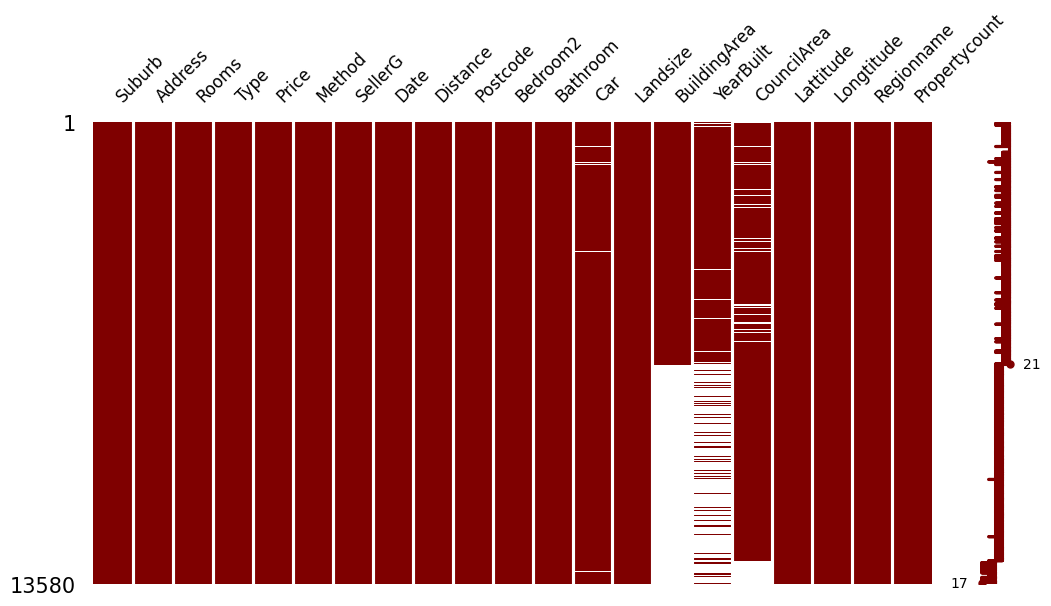

In [24]:
sorted_df = melb_data.sort_values('BuildingArea')
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

#### 1.9.2 Detección de correlaciones usando Heatmap

El heatmap muestra correlaciones entre columnas que tienen datos faltantes.

| Correlación | Interpretación |
|---|---|
| **-1** | Si el valor de una variable está presente, en la otra está ausente |
| **0** | No se puede ver una relación lineal |
| **+1** | Si una variable tiene valor, la otra definitivamente también |

<Axes: >

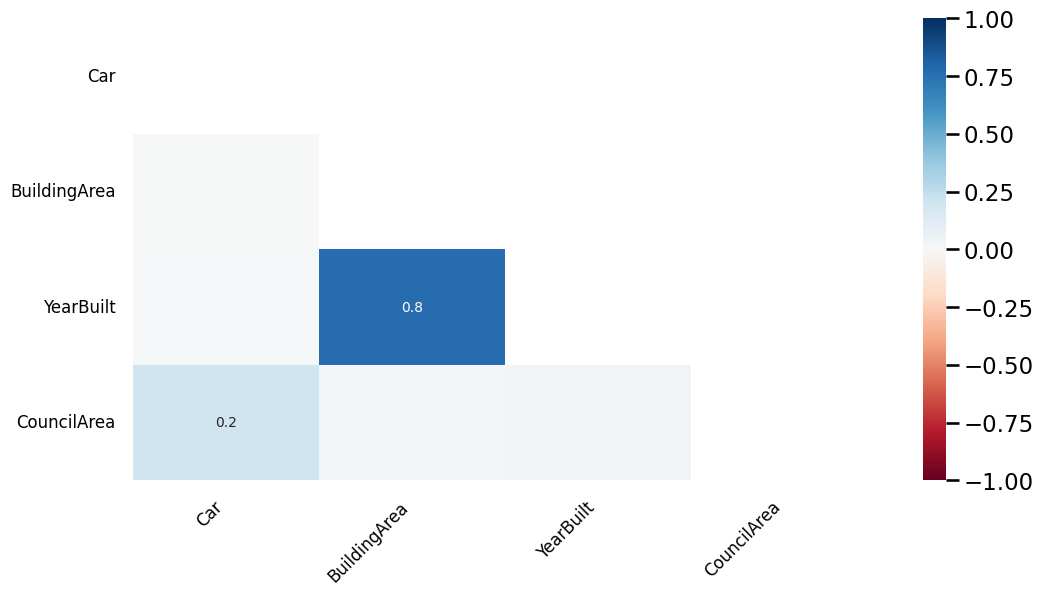

In [25]:
msno.heatmap(melb_data, figsize=(12, 6), fontsize=12)

La aleatoriedad no es completa: hay **alta correlación entre `YearBuilt` y `BuildingArea`**. Esto sugiere un mecanismo **MAR** — ambas tienden a faltar juntas, posiblemente en propiedades más antiguas donde esta información no fue registrada.

Aún así, es posible utilizar imputación estocástica controlando el nivel de error.

## 2. Tratamiento del valor faltante

![diagrama-datos-faltantes.png](https://github.com/DiploDatos/AnalisisYCuracion/blob/master/diagrama-datos-faltantes.png?raw=true)

La decisión de qué hacer con los datos faltantes depende del **mecanismo de pérdida** identificado en la sección anterior:

| Mecanismo | Estrategia recomendada |
|---|---|
| **MCAR** | Eliminación de casos es aceptable si el % es pequeño |
| **MAR** | Imputación (básica o avanzada) usando otras variables |
| **MNAR** | Imputación avanzada; tratar con mucho cuidado los sesgos |

### 2.1 Eliminación de datos faltantes

Si la pérdida es completamente aleatoria (MCAR), las operaciones simples de Pandas que ignoran NaN no se ven afectadas. Sin embargo, operaciones más complejas pueden verse afectadas.

#### 2.1.1 Eliminación de **casos** completos

Si la pérdida es MCAR y el porcentaje de casos con datos faltantes es pequeño, se elimina el caso completo.

In [26]:
# La media de Car (pandas omite NaN automáticamente)
print(f"Media de Car (con NaN): {melb_df['Car'].mean():.2f}")

Media de Car (con NaN): 1.61


In [27]:
melb_df.dropna(subset=['Car'], how='any', inplace=True)
print(f"NaN en Car después de eliminar: {melb_df['Car'].isnull().sum()}")

NaN en Car después de eliminar: 0


Text(0.5, 1.0, 'Completitud después de eliminar casos con Car=NaN')

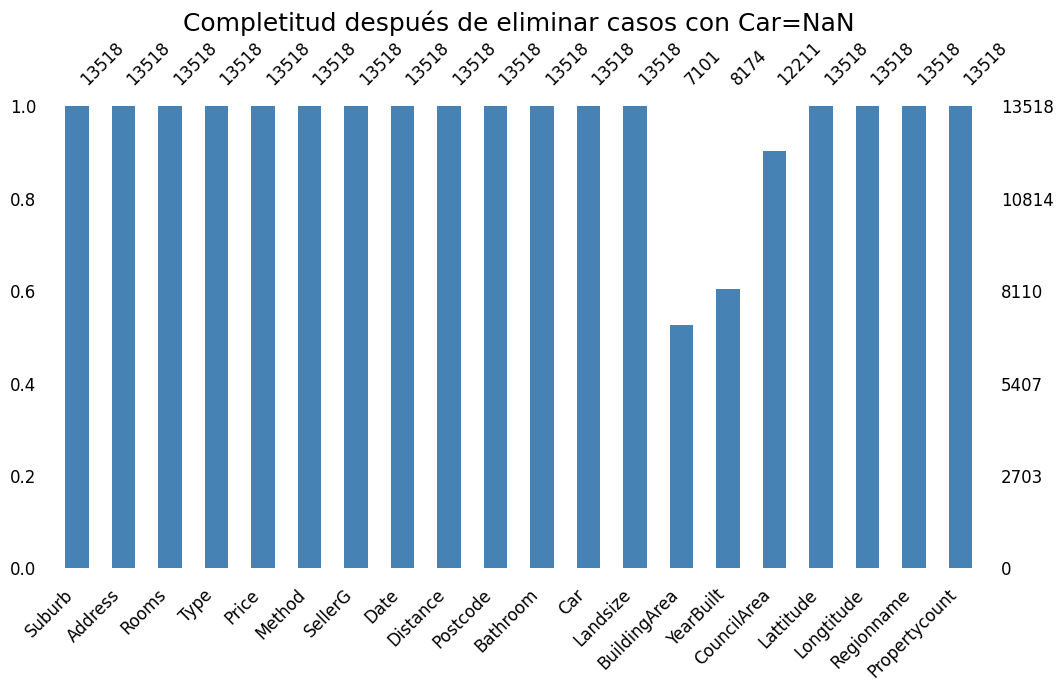

In [28]:
msno.bar(melb_df, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Completitud después de eliminar casos con Car=NaN')

#### 2.1.2 Eliminación de variables

Si una columna contiene **muchos valores faltantes** (>80%) y no es significativa, puede eliminarse. Sin embargo, no es una buena metodología en general ya que se pierde información útil.

> ⚠️ Además, si los datos de prueba tienen faltantes donde los datos de entrenamiento no los tienen, se producirá un error en el modelo.

**Eliminación de todas las columnas con datos faltantes** (solo para ilustrar):

<Axes: >

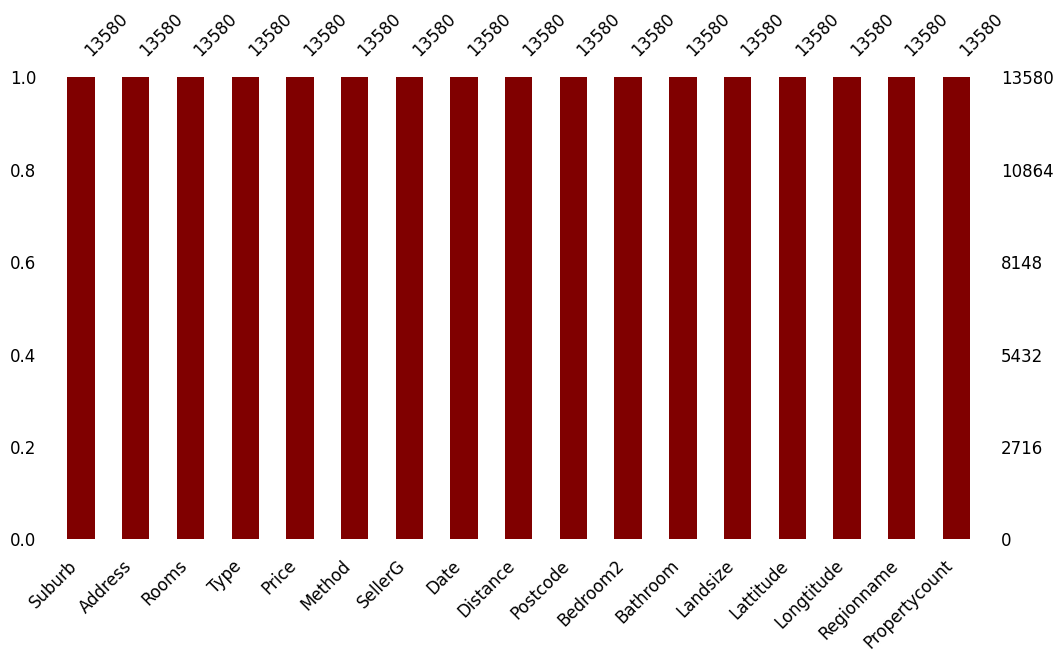

In [29]:
melb_data_without_missing = melb_data.dropna(axis=1)
msno.bar(melb_data_without_missing, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

**Eliminación de `CouncilArea`** — variable categórica con muchos faltantes y baja relevancia predictiva:

Text(0.5, 1.0, 'Completitud después de eliminar CouncilArea')

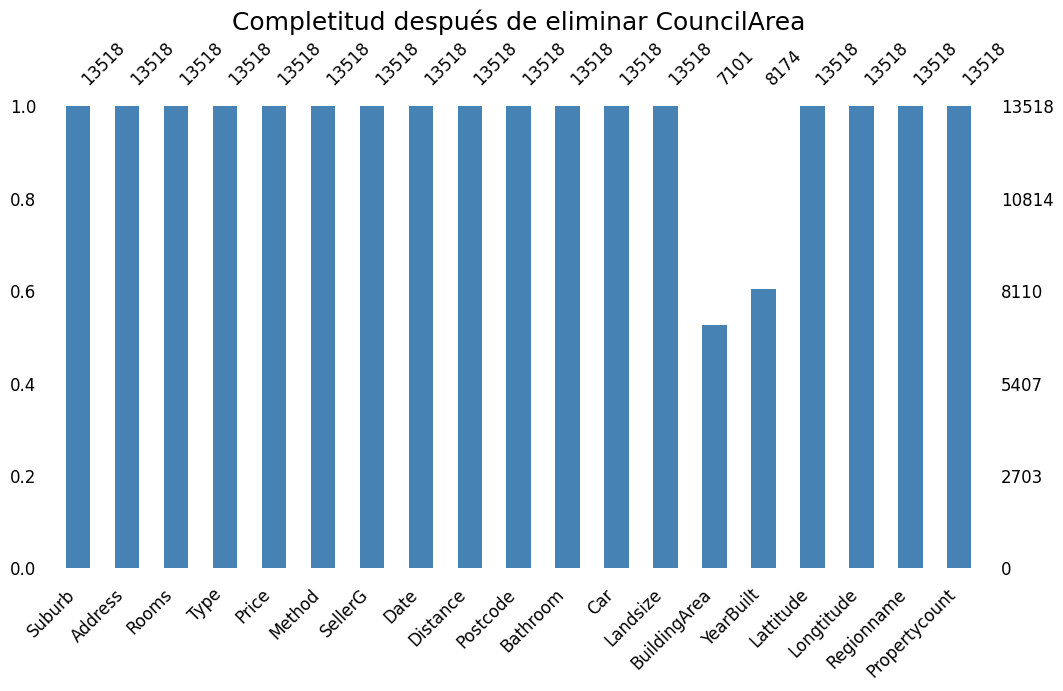

In [30]:
melb_df = melb_df.drop('CouncilArea', axis=1)
msno.bar(melb_df, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Completitud después de eliminar CouncilArea')

### 2.2 Técnicas de imputación

Imputar refiere a reemplazar datos faltantes con valores sustitutos. Según la complejidad, se clasifican en **básicas** y **avanzadas**.

**Técnicas básicas** — reemplazan el dato faltante por:
- Un valor constante con significado en el dominio.
- La media, mediana o moda de la columna.
- Un valor de otro registro seleccionado al azar.

**Técnicas avanzadas** — reemplazan el dato faltante por:
- Un valor estimado por un modelo predictivo.

#### 2.2.1 Técnicas Básicas — Imputar con constante

Text(0.5, 1.0, 'Después de imputar con constante (0)')

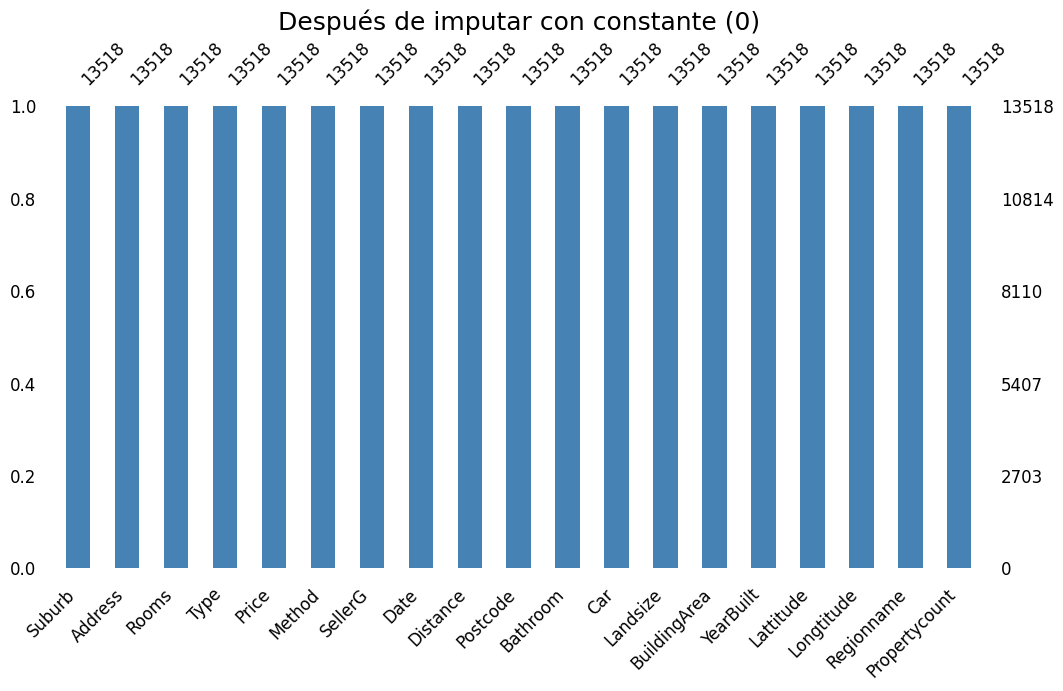

In [31]:
from sklearn.impute import SimpleImputer

melb_data_constant = melb_df.copy()

# Imputar con cero (constante)
mean_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0)
melb_data_constant.iloc[:, :] = mean_imputer.fit_transform(melb_data_constant)

msno.bar(melb_data_constant, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputar con constante (0)')

In [32]:
melb_data_constant.sample(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount
10384,Malvern,13 Nicholls St,3,h,1700000.00,PI,Jellis,27/05/2017,5.90,3144.00,2.00,0.00,312.00,141.00,1920.00,-37.86,145.03,Southern Metropolitan,4675.00
6354,Toorak,1/21 Bruce St,1,u,349000.00,PI,Williams,7/05/2016,4.60,3142.00,1.00,1.00,0.00,38.00,1958.00,-37.84,145.01,Southern Metropolitan,7217.00
11904,Braybrook,35 Carlton St,3,h,800000.00,S,Biggin,29/07/2017,8.60,3019.00,1.00,2.00,591.00,0.00,0.00,-37.78,144.85,Western Metropolitan,3589.00
8025,Keilor East,1/77 Lincoln Dr,3,t,745000.00,S,Barry,20/05/2017,12.80,3033.00,2.00,1.00,224.00,0.00,0.00,-37.74,144.87,Western Metropolitan,5629.00
1597,Camberwell,8/1277 Toorak Rd,2,u,530000.00,PI,Ross,17/09/2016,7.80,3124.00,1.00,1.00,0.00,76.00,1960.00,-37.85,145.09,Southern Metropolitan,8920.00
8221,Pascoe Vale,5/137 Northumberland Rd,3,t,560000.00,S,Nelson,20/05/2017,9.90,3044.00,2.00,1.00,141.00,94.00,2009.00,-37.72,144.93,Northern Metropolitan,7485.00
13279,Reservoir,20 York St,3,h,1400000.00,S,Raine,23/09/2017,12.00,3073.00,1.00,6.00,667.00,115.00,1920.00,-37.73,144.99,Northern Metropolitan,21650.00
2818,Glen Iris,33A Scott Gr,3,h,1710000.00,S,Noel,18/03/2017,9.20,3146.00,1.00,3.00,557.00,0.00,0.00,-37.86,145.05,Southern Metropolitan,10412.00
13102,Balwyn North,85 Clifton St,4,h,1400000.00,VB,hockingstuart,23/09/2017,9.70,3104.00,2.00,1.00,629.00,0.00,0.00,-37.79,145.10,Southern Metropolitan,7809.00
7890,Glen Iris,28 Martin Rd,3,h,1601000.00,S,Marshall,20/05/2017,9.20,3146.00,1.00,2.00,453.00,102.00,1930.00,-37.85,145.06,Southern Metropolitan,10412.00


**Pros:**
- Trabaja con variables categóricas **sin necesidad de encodings**, agregando una categoría más.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Puede introducir **sesgos** en los datos.
- Tiene sentido solo cuando la categoría a agregar tiene significado en el dominio.

#### 2.2.2 Imputar con el valor más frecuente

In [ ]:
melb_data_most_frequent = melb_df.copy()

mean_imputer = SimpleImputer(strategy='most_frequent')
melb_data_most_frequent.iloc[:, :] = mean_imputer.fit_transform(melb_data_most_frequent)

msno.bar(melb_data_most_frequent, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputar con valor más frecuente')

In [ ]:
melb_data_most_frequent.sample(10)

**Pros:**
- Anda bien con variables categóricas **sin necesidad de encodings**.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Puede introducir **sesgos** en los datos.

#### 2.2.3 Ejercicio: Imputar con la media

Imputar las columnas con datos faltantes utilizando la **media**. Recuerda que este método:

**Pros:**
- Rápido y fácil.
- Anda bien con datasets numéricos bien balanceados.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Solo trabaja a nivel de columna.
- **No debe usarse con variables categóricas**.
- No es muy preciso y no hay cómputo para el error.

In [ ]:
# Ejercicio: completar el código
melb_data_mean = melb_df.copy()

mean_imputer = SimpleImputer(strategy='mean')  # estrategia: media
# Tu código aquí ↓

# melb_data_mean.iloc[:, :] = ...
# msno.bar(...)

#### 2.2.4 Hot Deck

> 💡 Este método fue cubierto en las slides de Semana 5.

El **Hot Deck** reemplaza los faltantes con valores obtenidos de registros que son los más similares en el mismo dataset. Es conceptualmente más sofisticado que imputar con constantes o medias.

**Ventajas:**
- Conceptualmente simple.
- Conserva los niveles de medición adecuados para las variables.
- Finaliza el proceso de imputación con un conjunto completo de datos.

**Desventajas:**
- La dificultad principal es definir qué es "similar".

La librería `fancyimpute` implementa una versión iterativa equivalente:

In [35]:
#Requiere: pip install fancyimpute
from fancyimpute import IterativeImputer

data_hotdeck = melb_df.copy()
data_hotdeck_numeric = data_hotdeck.select_dtypes(include='number')

imputer = IterativeImputer(imputation_order='ascending')
data_imputed = imputer.fit_transform(data_hotdeck_numeric)

print("DataFrame imputado con Hot Deck:")
print(pd.DataFrame(data_imputed, columns=data_hotdeck_numeric.columns).sample(5))
print("Descomenta las líneas anteriores si tienes instalado fancyimpute.")

DataFrame imputado con Hot Deck:
      Rooms      Price  Distance  Postcode  Bathroom  Car  Landsize  \
6936   3.00  782000.00     12.40   3060.00      1.00 2.00    628.00   
1602   4.00 4760000.00      7.80   3124.00      2.00 2.00    903.00   
2450   3.00 1150000.00      8.00   3040.00      1.00 0.00    300.00   
1875   4.00 1260000.00     13.60   3148.00      2.00 2.00    500.00   
1373   3.00 1020000.00      5.20   3056.00      1.00 3.00    308.00   

      BuildingArea  YearBuilt  Lattitude  Longtitude  Propertycount  
6936        182.89    1966.89     -37.72      144.96        5070.00  
1602        354.89    1879.48     -37.82      145.06        8920.00  
2450        145.00    1900.00     -37.75      144.93        9264.00  
1875        277.00    2001.00     -37.88      145.10        3582.00  
1373        119.00    1943.00     -37.76      144.96       11918.00  
Descomenta las líneas anteriores si tienes instalado fancyimpute.


### 2.3 Técnicas de imputación avanzadas

Las técnicas avanzadas usan **algoritmos de aprendizaje automático** para imputar los valores del dataset, a diferencia de los métodos anteriores que usan otros valores de la misma columna.

### 2.3.1 K-Nearest Neighbor Imputation

KNN imputa valores faltantes encontrando los **k vecinos más cercanos** a la observación con datos perdidos y asignando el valor basado en los vecinos.

**Parámetros clave:**
- `n_neighbors`: número de vecinos más cercanos a considerar.
- `weights`: ponderación de los vecinos. `"uniform"` = todos contribuyen igual; `"distance"` = los más cercanos pesan más.

> ⚠️ KNN requiere que los datos estén **estandarizados** (diferentes escalas introducen valores sesgados).

Text(0.5, 1.0, 'Después de imputación KNN')

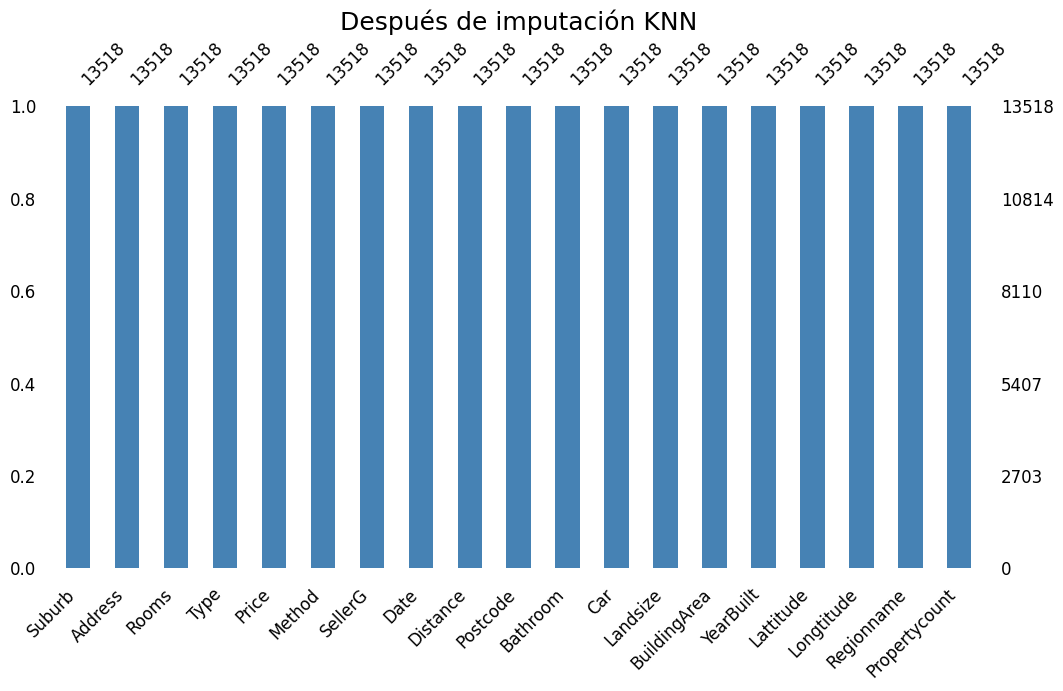

In [36]:
melb_data_knn = melb_df.copy(deep=True)

knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
melb_data_knn[['YearBuilt', 'BuildingArea']] = knn_imputer.fit_transform(
    melb_data_knn[['YearBuilt', 'BuildingArea']])

msno.bar(melb_data_knn, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputación KNN')

In [ ]:
melb_data_knn.sample(10)

**Pros:**
- Considera la relación entre observaciones.
- Más preciso que métodos basados en estadísticos simples.

**Cons:**
- Usa distancias calculadas con los casos (incluso cuando tienen NaN).
- Requiere **codificación de variables categóricas** antes de imputar.
- Precisa que los datos estén estandarizados (`MinMaxScaler` de Scikit-Learn escala al rango [0, 1]).
- `CouncilArea` **no puede imputarse** sin encoding previo.

### 2.3.2 Multivariate feature imputation (MICE)

> 💡 Este método fue cubierto en detalle en las slides de Semana 5.

**MICE** (*Multivariate Imputation by Chained Equations*) es una estrategia que modela cada variable con valores faltantes como función de otras variables en forma rotatoria.

**Proceso (4 pasos repetidos por variable):**
1. **Paso 1** — Imputación simple inicial (media/moda) para completar todos los faltantes.
2. **Paso 2** — Se vuelve a poner `NA` en una variable X a imputar.
3. **Paso 3** — Se ajusta un modelo usando las demás variables completas para predecir X.
4. **Paso 4** — Los faltantes de X se reemplazan por las predicciones del modelo.

Los pasos 2–4 se repiten para cada variable con faltantes (= 1 ciclo). El proceso itera ~10 veces.

> 💡 MICE opera bajo el supuesto de que el mecanismo es **MAR**.

In [ ]:
melb_data_mice = melb_df.copy(deep=True)

mice_imputer = IterativeImputer(random_state=0, estimator=BayesianRidge())
melb_data_mice[['YearBuilt', 'BuildingArea']] = mice_imputer.fit_transform(
    melb_data_mice[['YearBuilt', 'BuildingArea']])

msno.bar(melb_data_mice, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputación MICE (BayesianRidge)')

In [ ]:
melb_data_mice.sample(10)

**Pros:**
- Versátil — puede utilizarse con diferentes clases de estimadores.
- No produce sesgo importante cuando el mecanismo es MAR.
- Se puede usar para cualquier tipo de análisis posterior.

**Cons:**
- La versión de Sklearn **no admite datos mixtos** — debe realizarse encoding primero.
- Puede ser costoso computacionalmente.
- Genera un dataset completo por cada iteración.

### 2.3.3 Ejercicio

Dado `melb_df`, imputar las columnas `YearBuilt` y `BuildingArea` con cada uno de los siguientes estimadores y comparar resultados:

- `BayesianRidge()`
- `DecisionTreeRegressor(max_features='sqrt', random_state=0)`
- `ExtraTreesRegressor(n_estimators=10, random_state=0)`
- `KNeighborsRegressor(n_neighbors=15)`

In [ ]:
estimators = {
    'BayesianRidge': BayesianRidge(),
    'DecisionTree': DecisionTreeRegressor(max_features='sqrt', random_state=0),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=10, random_state=0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=15)
}

# Tu código aquí ↓
# Para cada estimador en estimators:
#   - Crear una copia de melb_df
#   - Imputar YearBuilt y BuildingArea con IterativeImputer(estimator=...)
#   - Mostrar estadísticos descriptivos de las columnas imputadas


### 2.3.4 Otros métodos de imputación

- **[miceforest](https://github.com/AnotherSamWilson/miceforest)** — MICE rápido con Random Forests. Puede imputar datos categóricos y numéricos sin mucha configuración.

- **[MissForest (missingpy)](https://towardsdatascience.com/missforest-the-best-missing-data-imputation-algorithm-4d01182aed3)** — Imputa usando Random Forests de forma iterativa.

- **[Datawig](https://github.com/awslabs/datawig)** — Imputación con Deep Learning. Funciona muy bien con características categóricas y no numéricas.

- **Stochastic regression imputation** — Similar a la imputación por regresión, pero agrega un residuo aleatorio para no subestimar la varianza.

- **Extrapolación e Interpolación** — Estima valores a partir de observaciones dentro del rango conocido.

- **Cold Deck** — Sustituye un valor constante derivado de fuentes externas o investigaciones previas. Tiene las mismas desventajas que imputar con la media.

### Conclusión

No existe una forma perfecta de compensar los valores perdidos. Cada estrategia puede funcionar mejor para ciertos conjuntos de datos y tipos de faltantes.

**Guía de decisión rápida:**

| Situación | Estrategia sugerida |
|---|---|
| Pocos faltantes, mecanismo MCAR | Eliminación de casos |
| Variable con >80% faltantes | Eliminación de variable |
| Faltantes en variable numérica, MAR | Imputación por media/mediana o KNN |
| Faltantes en variable categórica | Imputación por moda o Hot Deck |
| Faltantes en múltiples variables relacionadas | MICE |
| MNAR | Modelado explícito del mecanismo; consultar con experto de dominio |

> La clave es siempre **entender por qué faltan los datos** antes de decidir qué hacer con ellos.